In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [28]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [29]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head()

,Feature1,Feature2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [30]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [31]:
inertia = []
K_range = range(1, 11)

In [32]:
for K in K_range:
    k_means = KMeans(n_clusters=K, random_state=42)
    k_means.fit(X_scaled)
    inertia.append(k_means.inertia_)

In [33]:
inertia

[1000.0,
 297.8954141051723,
 11.57548472310498,
 9.752067977356841,
 8.257175272446284,
 6.9175773204168,
 6.334755391595291,
 5.704177177901429,
 5.060234133532076,
 4.762361898130396]

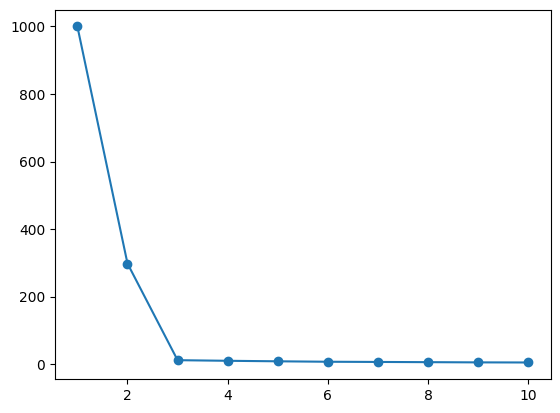

In [34]:
plt.plot(K_range, inertia, marker = 'o')

In [35]:
kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [36]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

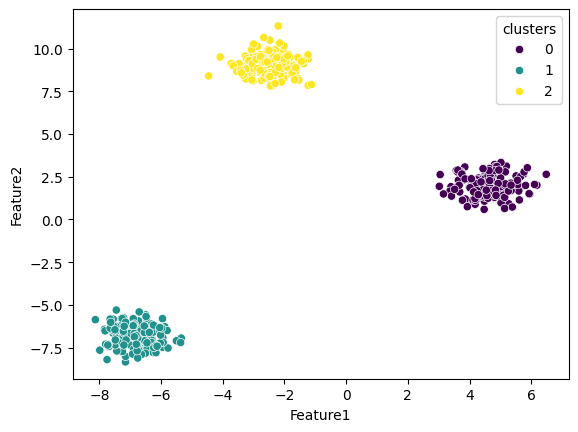

In [37]:
sns.scatterplot(x = df['Feature1'],
                y = df['Feature2'],
                hue = df['clusters'],
                palette= 'viridis')

In [38]:
# DBSCAN
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, DBSCAN
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [39]:
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])
df.head()

,Feature1,Feature2
0,0.830586,-0.447733
1,0.701678,0.816918
2,1.022080,-0.492571
3,-0.316765,0.953438
4,0.293226,1.057185


In [40]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [41]:
kmeans_final = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

In [42]:
df['clusters'] = cluster_labels

<Axes: xlabel='Feature1', ylabel='Feature2'>

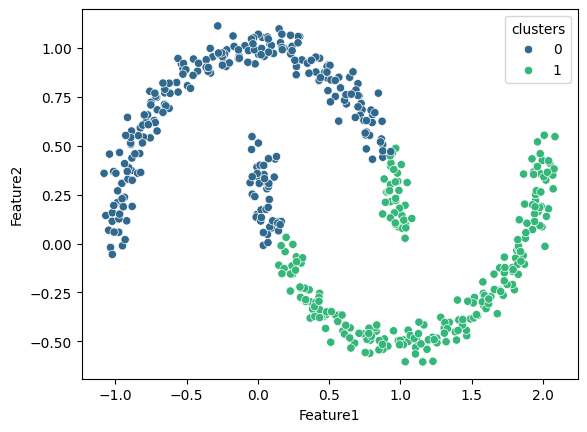

In [43]:
sns.scatterplot(x = df['Feature1'],
                y = df['Feature2'],
                hue = df['clusters'],
                palette= 'viridis')

In [44]:
dbscan = DBSCAN(eps=0.3, min_samples=5)
results = dbscan.fit_predict(X_scaled)

In [45]:
df['dbscan'] = results

<Axes: xlabel='Feature1', ylabel='Feature2'>

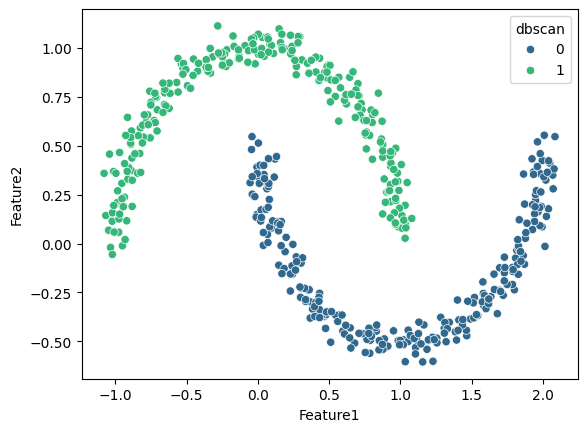

In [46]:
sns.scatterplot(x = df['Feature1'],
                y = df['Feature2'],
                hue = df['dbscan'],
                palette= 'viridis')